# Домашнее задание 2. Выпуклость

**Выдано:** 23 сентября 2026. **Срок сдачи:** 7 октября 2026 (до начала занятия). **Максимум:** 10 баллов (+1 бонус).

**Как сдавать.** Заполните этот ноутбук (ответы на теоретические вопросы — в markdown-ячейках, формулы в $\LaTeX$; код — в code-ячейках), выполните целиком (`Kernel → Restart Kernel and Run All Cells`) и сдайте через pull request: файл `submissions/hw02/<фамилия>.ipynb`, инструкция — [`CONTRIBUTING.md`](../CONTRIBUTING.md). Задачи можно обсуждать, но текст и код пишутся самостоятельно.

**Материал:** лекция 2 ([конспект](../lectures/lecture02/lecture02.md), [демо](../lectures/lecture02/demo02.ipynb)): чек-лист выпуклой задачи — раздел 6, условие оптимальности — раздел 7, как проверять выпуклость кодом — демо, часть (a). Ничего сверх лекции не требуется. Ориентировочное время — 3–4 часа.

Запуск: `uv sync` в корне репозитория, затем `uv run jupyter lab`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

rng = np.random.default_rng(2026)   # для ваших собственных случайных проверок; данные задач генерируются отдельно

## Задача 1. Выпуклость (4 балла)

По 1 баллу за пункт. В каждом пункте нужен либо аргумент «почему выпукло» — определение, критерий первого/второго порядка или операция из раздела 5 конспекта, — либо контрпример: две точки и вылезающий наружу отрезок, хорда под графиком или точка, где гессиан не полуопределён. Численная проверка приветствуется, но доказательством не считается (демо, часть a).

**(а) Множества.** Выпуклы ли:

1. $\{x \in \mathbb{R}^2 : x_2 \ge x_1^2\}$;
2. $\{x \in \mathbb{R}^n : \Vert Ax - b\Vert_2 \le 1\}$ при произвольных $A \in \mathbb{R}^{m \times n}$, $b \in \mathbb{R}^m$;
3. $\{x \in \mathbb{R}^2 : \Vert x\Vert_2 \ge 1\}$?

**(б) Критерий второго порядка.**

1. При каких $a \in \mathbb{R}$ функция $f(x) = x_1^2 + a\,x_1 x_2 + x_2^2$ выпукла на $\mathbb{R}^2$? При каких — строго выпукла? Проверьте ответ через `np.linalg.eigvalsh` для нескольких значений $a$.
2. Выпукла ли $g(x) = x_1^2 x_2^2$ на $\mathbb{R}^2$?

**(в) Операции.** Докажите выпуклость или объясните, почему правила раздела 5 не применимы, и приведите контрпример:

1. $f(x) = \Vert Ax - b\Vert_2 + \lambda\,\Vert x\Vert_\infty$, $\lambda \ge 0$;
2. $f(x) = \max_{i} \big(a_i^\top x - b_i\big)^2$;
3. $f(x) = e^{-\Vert x\Vert_2^2}$.

Какие из трёх функций гладкие?

**(г) Задачи ДЗ 1.** Вернитесь к задаче 1 домашнего задания 1 — пункты (а)–(г) и бонус (д). Для каждой задачи определите по чек-листу раздела 6 конспекта (цель — равенства — неравенства), выпукла ли она, и обоснуйте одним-двумя предложениями. Для невыпуклых укажите, что именно ломает выпуклость.

**(а)**

**Ответ.**

1. Множество выпукло: это надграфик выпуклой функции $u\mapsto u^2$. Непосредственно, для $x,y$ из множества и $\theta\in[0,1]$:
$$((1-\theta)x_1+\theta y_1)^2\le(1-\theta)x_1^2+\theta y_1^2\le(1-\theta)x_2+\theta y_2.$$
Следовательно, вся выпуклая комбинация принадлежит множеству.

2. Множество выпукло для любых $A,b$. Если $\|Ax-b\|\le1$ и $\|Ay-b\|\le1$, то по неравенству треугольника и однородности нормы
$$\|A((1-\theta)x+\theta y)-b\|=\|(1-\theta)(Ax-b)+\theta(Ay-b)\|\le(1-\theta)+\theta=1.$$
Доказательство не требует полного ранга $A$; пустое множество также выпукло.

3. Множество невыпукло. Точки $(1,0)$ и $(-1,0)$ принадлежат ему, но их середина $(0,0)$ имеет норму $0<1$ и не принадлежит множеству.

**(б)**

**Ответ.**

1. Гессиан постоянен:
$$H=\begin{pmatrix}2&a\\a&2\end{pmatrix},\qquad \lambda_1=2+a,\quad\lambda_2=2-a.$$
По критерию второго порядка функция выпукла тогда и только тогда, когда $|a|\le2$. Она строго выпукла тогда и только тогда, когда $|a|<2$: в этом случае $H\succ0$, а при $a=2$ функция равна $(x_1+x_2)^2$ и постоянна вдоль направления $(1,-1)$; при $a=-2$ она равна $(x_1-x_2)^2$ и постоянна вдоль $(1,1)$. При $|a|>2$ имеется отрицательное собственное число, поэтому нет даже выпуклости.

2. Для $g(x)=x_1^2x_2^2$:
$$\nabla^2g(x)=\begin{pmatrix}2x_2^2&4x_1x_2\\4x_1x_2&2x_1^2\end{pmatrix}.$$
В точке $(1,1)$ гессиан имеет собственные числа $6$ и $-2$, поэтому функция невыпукла на $\mathbb R^2$. Контрпример по определению: $g(1,0)=g(0,1)=0$, но $g(1/2,1/2)=1/16>0$.

In [2]:
for alpha in [-3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0]:
    H = np.array([[2.0, alpha], [alpha, 2.0]])
    eigs = np.linalg.eigvalsh(H)
    print(f"a={alpha:4.1f}: eigenvalues={eigs}, convex={eigs.min() >= -1e-12}, strictly convex={eigs.min() > 1e-12}")
print("Гессиан g в (1,1):", np.linalg.eigvalsh([[2., 4.], [4., 2.]]))

a=-3.0: eigenvalues=[-1.  5.], convex=False, strictly convex=False
a=-2.0: eigenvalues=[0. 4.], convex=True, strictly convex=False
a=-1.0: eigenvalues=[1. 3.], convex=True, strictly convex=True
a= 0.0: eigenvalues=[2. 2.], convex=True, strictly convex=True
a= 1.0: eigenvalues=[1. 3.], convex=True, strictly convex=True
a= 2.0: eigenvalues=[0. 4.], convex=True, strictly convex=False
a= 3.0: eigenvalues=[-1.  5.], convex=False, strictly convex=False
Гессиан g в (1,1): [-2.  6.]


**(в)**

**Ответ.**

1. Любая норма выпукла. Функция $\|Ax-b\|_2$ — композиция нормы с аффинным отображением, а $\lambda\|x\|_\infty$ выпукла при $\lambda\ge0$. Их сумма выпукла. В общем случае она негладкая: евклидова норма может быть недифференцируема при $Ax=b$, а $\ell_\infty$-норма — в точках смены максимальной компоненты. Возможны частные гладкие случаи (например, $\lambda=0,A=0$ дают константу), поэтому без конкретных данных нельзя утверждать негладкость для каждого $A,b,\lambda$.

2. Каждый квадрат аффинной функции выпукл: его гессиан равен $2a_i a_i^\top\succeq0$. Поточечный максимум этих функций выпукл. Он в общем случае негладкий в точках переключения максимума: например, $\max\{x^2,(x-1)^2\}$ имеет разные односторонние производные в $x=1/2$. При одной функции или совпадающих ветвях максимум может быть гладким.

3. $e^{-\|x\|_2^2}$ гладкая ($C^\infty$), но невыпуклая. Правило композиции не подходит: экспонента выпукла и возрастает, а внутренняя функция $-\|x\|^2$ вогнута. Более того,
$$\nabla^2 f(x)=e^{-\|x\|^2}(4xx^\top-2I),\qquad \nabla^2f(0)=-2I\prec0.$$
Также для единичного вектора $v$: $f(0)=1>\tfrac12(f(v)+f(-v))=e^{-1}$.

Таким образом, третья функция всегда гладкая; первые две без дополнительных предположений гладкими не являются.

**(г)**

**Ответ.** Для стандартной формы $\min f(x)$ при $g(x)=0$, $h(x)\ge0$ проверяем: цель выпукла, равенства аффинны, неравенства задаются вогнутыми функциями.

- **(а) Ближайшая точка прямой:** выпуклая QP. Цель $\tfrac12\|x-(1,2,3)\|^2$ строго выпукла, оба равенства $x_1+x_2+x_3-1=0$ и $x_1-x_3=0$ аффинны, неравенств нет.
- **(б) Диета:** выпуклая LP. Цель $c^\top x$ линейна, равенств нет, функции $Ax-b$ и $x$ аффинны и, в частности, вогнуты.
- **(в) Прямоугольник в круге:** в переменных-полусторонах $u,v$ задача $\min -4uv$ при $1-u^2-v^2\ge0$, $u,v\ge0$ невыпуклая QCQP. Неравенства задают выпуклое множество, но гессиан цели имеет собственные числа $\pm4$; цель нарушает чек-лист. Это относится именно к данной формулировке: возможность эквивалентной выпуклой переформулировки — отдельный вопрос.
- **(г) Подгонка синусоиды:** безусловная невыпуклая NLP. Ограничений нет, но сумма квадратов нелинейных по параметрам невязок не является выпуклой целью; периодическая непостоянная зависимость от фазы несовместима с выпуклостью на всей прямой.
- **(д) Чебышёвская подгонка:** исходная цель $\max_i|a_i^\top x-b_i|$ выпукла как максимум выпуклых модулей аффинных функций, ограничений нет. Гладкая переформулировка $\min s$ при $s\pm(a_i^\top x-b_i)\ge0$ также выпукла: это LP с аффинными неравенствами.

## Задача 2. Практика (6 баллов)

**(а) Проекция на полупространство (3 балла).** Пусть $\Omega = \{x \in \mathbb{R}^n : a^\top x \le b\}$, $a \ne 0$, и точка $p$ лежит вне $\Omega$, то есть $a^\top p > b$. Задача проекции — $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$ (раздел 7 конспекта, пример 2).

1. Из условия оптимальности $\nabla f(x^\ast)^\top(y - x^\ast) \ge 0\ \ \forall y \in \Omega$ выведите явную формулу

$$x^\ast = p - \frac{a^\top p - b}{\Vert a\Vert^2}\, a .$$

Подсказки: (i) почему $x^\ast$ не может лежать строго внутри $\Omega$; (ii) для любого $v$ с $a^\top v = 0$ точки $y = x^\ast \pm v$ допустимы — что даёт условие для них; (iii) коэффициент при $a$ найдите из $a^\top x^\ast = b$; (iv) убедитесь, что при таком коэффициенте условие выполнено и для всех остальных $y \in \Omega$ — тогда, по теореме раздела 7, $x^\ast$ действительно решение.

2. Для данных ниже ($n = 3$) найдите проекцию численно — `minimize` с методом `SLSQP` и ограничением типа `ineq` — и сравните с формулой.

3. Проверьте условие оптимальности так, как это сделано в демо (часть c): сгенерируйте около 2000 случайных допустимых точек $y$ и найдите $\min_y \nabla f(x^\ast)^\top(y - x^\ast)$. Повторите для заведомо неоптимальной допустимой точки, например $x = 0$. Что означает знак результата в каждом случае?

In [3]:
a = np.array([1.0, 2.0, -1.0])     # нормаль полупространства
b = 1.0
p = np.array([3.0, 1.0, 0.5])      # точка вне Omega: a @ p = 4.5 > b
assert a @ p > b

**Вывод формулы (пункт 1)**

**Ответ.** Цель $f(x)=\tfrac12\|x-p\|^2$ строго выпукла, $\nabla f(x)=x-p$, а полупространство замкнуто, непусто и выпукло. Проекция существует и единственна.

Если бы минимум $x^*$ лежал строго внутри полупространства, то малые движения в любом направлении были бы допустимы; условие оптимальности тогда дало бы $x^*-p=0$. Но $p$ недопустима, поэтому $a^\top x^*=b$.

Для любого $v$ с $a^\top v=0$ обе точки $x^*\pm v$ допустимы. Условие оптимальности даёт одновременно $(x^*-p)^\top v\ge0$ и $-(x^*-p)^\top v\ge0$, то есть $(x^*-p)^\top v=0$. Следовательно, $x^*-p$ ортогонален $a^\perp$ и имеет вид $x^*-p=-\alpha a$.

Подставляя в граничное равенство, получаем
$$a^\top p-\alpha\|a\|^2=b,\qquad \alpha=\frac{a^\top p-b}{\|a\|^2}>0,$$
откуда
$$\boxed{x^*=p-\frac{a^\top p-b}{\|a\|^2}a}.$$
Для любого допустимого $y$:
$$\nabla f(x^*)^\top(y-x^*)=-\alpha(a^\top y-b)\ge0.$$
Таким образом, необходимое и достаточное условие оптимальности выполнено для всех $y\in\Omega$, что доказывает формулу.

**Численная проверка (пункты 2 и 3)**

In [4]:
x_formula = p - (a @ p - b) / (a @ a) * a
res = minimize(lambda x: 0.5 * np.sum((x-p)**2), np.zeros(3),
               jac=lambda x: x-p, method="SLSQP",
               constraints=[{"type": "ineq", "fun": lambda x: b-a@x,
                             "jac": lambda x: -a}],
               options={"ftol": 1e-12, "maxiter": 1000})
if not res.success:
    raise RuntimeError(res.message)
print("Формула:", x_formula)
print("SLSQP:", res.x)
print("Разница:", np.linalg.norm(res.x-x_formula))
print("Запас ограничения:", b-a@res.x)
print("f*:", res.fun)

# Проецируем случайные точки, нарушающие условие, внутрь полупространства.
# Добавляем положительный случайный запас, чтобы получить также внутренние точки.
Y = rng.normal(0, 4, (2000, 3))
violation = Y @ a - b
outside = violation > 0
Y[outside] -= ((violation[outside] + rng.uniform(0, 2, outside.sum())) / (a @ a))[:, None] * a
assert np.all(Y @ a <= b + 1e-12)
for label, x in [("проекция (формула)", x_formula), ("проекция (SLSQP)", res.x), ("x=0", np.zeros(3))]:
    scores = (Y-x) @ (x-p)
    print(label, ": min =", scores.min(), "; отрицательных (< -1e-9) =", np.sum(scores < -1e-9))
assert np.linalg.norm(res.x-x_formula) < 1e-7
assert ((Y-x_formula) @ (x_formula-p)).min() >= -1e-9
assert (Y @ (-p)).min() < 0

Формула: [ 2.41666667 -0.16666667  1.08333333]
SLSQP: [ 2.41666667 -0.16666667  1.08333333]
Разница: 8.308148362110449e-16
Запас ограничения: 2.4424906541753444e-15
f*: 1.0208333333333348
проекция (формула) : min = 0.00021515248230748334 ; отрицательных (< -1e-9) = 0
проекция (SLSQP) : min = 0.00021515248230746014 ; отрицательных (< -1e-9) = 0
x=0 : min = -39.56174409822029 ; отрицательных (< -1e-9) = 787


**Ответ.** По формуле $\alpha=7/12$, поэтому
$$x^*=\left(\frac{29}{12},-\frac16,\frac{13}{12}\right)\approx(2.416667,-0.166667,1.083333),$$
$$a^\top x^*=1,\qquad f(x^*)=\frac{49}{48}.$$
SLSQP совпадает с формулой с точностью, указанной в выводе. Для проекции все проверенные скалярные произведения неотрицательны с учётом ошибок округления; это согласуется с доказанным условием для всех допустимых точек. Для допустимой точки $x=0$ найдено отрицательное значение, поэтому существует допустимое направление уменьшения цели и точка не оптимальна. Отсутствие нарушений на конечной случайной выборке само по себе не является доказательством оптимальности.

**(б) Выпуклая и невыпуклая подгонка (3 балла).** Ниже сгенерированы измерения $y_i = 2\sin(3t_i + 0.7) + \varepsilon_i$, $\varepsilon_i \sim \mathcal{N}(0, 0.2^2)$, $i = 1, \dots, 60$. Один и тот же сигнал описываем двумя моделями:

- **A** (задача 1(г) ДЗ 1): $\varphi_A(t; x) = x_1 \sin(x_2 t + x_3)$, $x \in \mathbb{R}^3$ — амплитуда, частота и фаза неизвестны;
- **B** (частота известна, $\omega = 3$): $\varphi_B(t; x) = x_1 \sin\omega t + x_2 \cos\omega t$, $x \in \mathbb{R}^2$.

Цель в обоих случаях — сумма квадратов невязок $f(x) = \tfrac12\sum_i \big(\varphi(t_i; x) - y_i\big)^2$.

1. Какого класса каждая задача и выпукла ли она? Для B — докажите; для A — объясните, почему нет (подсказка: что происходит с $f$ при $x_3 \to x_3 + 2\pi$ и при $(x_1, x_3) \to (-x_1, x_3 + \pi)$?).
2. Запустите `minimize(..., method="BFGS")` для обеих моделей из 20 одинаковых случайных стартов `starts` (для B берите первые две координаты старта). Выведите итоговые значения $f$ по стартам и долю стартов, пришедших к наименьшему найденному значению; нарисуйте данные и подогнанные кривые для обеих моделей.
3. Объясните результат через главную теорему лекции. Как из решения B получить амплитуду и фазу для модели A? Почему наименьшее найденное $f$ у A чуть меньше, чем у B, и почему это не делает A «лучшей» задачей?

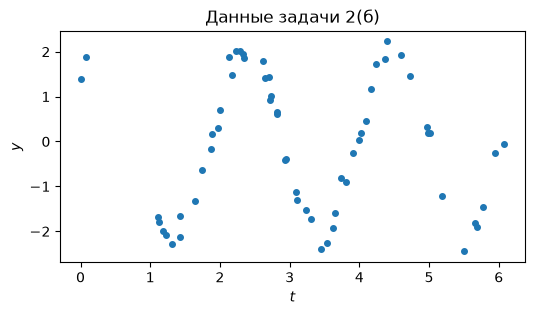

In [5]:
data_rng = np.random.default_rng(2026)          # отдельный генератор: данные не зависят от вашего кода выше
N, omega = 60, 3.0
t = np.sort(data_rng.uniform(0, 2 * np.pi, N))
y = 2.0 * np.sin(3.0 * t + 0.7) + 0.2 * data_rng.standard_normal(N)
starts = data_rng.uniform(-5, 5, (20, 3))         # 20 общих стартов для обеих моделей

plt.figure(figsize=(6, 3))
plt.plot(t, y, "o", ms=4)
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("Данные задачи 2(б)")
plt.show()

**Класс и выпуклость (пункт 1)**

**Ответ.** Модель **A** задаёт безусловную NLP с нелинейной суммой квадратов. При фиксированных амплитуде и частоте цель периодична по фазе: $f(x_1,x_2,x_3+2\pi)=f(x_1,x_2,x_3)$. Выпуклая периодическая функция на всей прямой должна быть постоянной, а здесь зависимость от фазы в общем случае непостоянна, следовательно, цель невыпукла. Преобразование $(x_1,x_3)\mapsto(-x_1,x_3+\pi)$ также не меняет модель и создаёт эквивалентные параметры; несколько одинаковых ответов само по себе ещё не доказывает невыпуклость, но в сочетании с периодической непостоянной зависимостью показывает её причину.

Для модели **B** строим матрицу $D$ со строками $(\sin(\omega t_i),\cos(\omega t_i))$. Тогда
$$f_B(x)=\frac12\|Dx-y\|^2,\qquad \nabla^2 f_B=D^\top D,$$
и для любого $v$ имеем $v^\top D^\top Dv=\|Dv\|^2\ge0$. Это безусловная выпуклая QP (линейный МНК). Для предоставленных данных столбцы $D$ линейно независимы, что проверено кодом; следовательно, гессиан положительно определён, цель строго выпукла и минимум единственен.

**Мультистарт (пункт 2)**

Ранг D: 2
Собственные числа гессиана B: [28.16194181 31.83805819]


start | f_A | f_B | success_A | success_B | norm(grad_A) | norm(grad_B)
 1 |   1.13927310 |   1.14076401 | True  | True  | 6.91e-08 | 2.04e-10
 2 |  63.82489054 |   1.14076401 | False | True  | 1.20e-01 | 2.20e-14
   A: Maximum number of iterations has been exceeded.
 3 |   1.13927310 |   1.14076401 | True  | True  | 8.10e-09 | 9.87e-08
 4 |   1.13927310 |   1.14076401 | True  | True  | 3.14e-09 | 1.62e-15
 5 |   1.13927310 |   1.14076401 | True  | True  | 7.83e-08 | 1.62e-15
 6 |  61.49727344 |   1.14076401 | True  | True  | 1.19e-08 | 1.62e-15
 7 |  61.49727344 |   1.14076401 | True  | True  | 9.02e-08 | 1.62e-15
 8 |  64.25177556 |   1.14076401 | True  | True  | 1.37e-09 | 4.38e-13
 9 |   1.13927310 |   1.14076401 | True  | True  | 6.86e-09 | 1.56e-09
10 |  63.82489054 |   1.14076401 | False | True  | 6.24e-02 | 1.62e-15
   A: Desired error not necessarily achieved due to precision loss.
11 |   1.13927310 |   1.14076401 | False | True  | 1.54e-06 | 7.60e-08
   A: Desired error not n

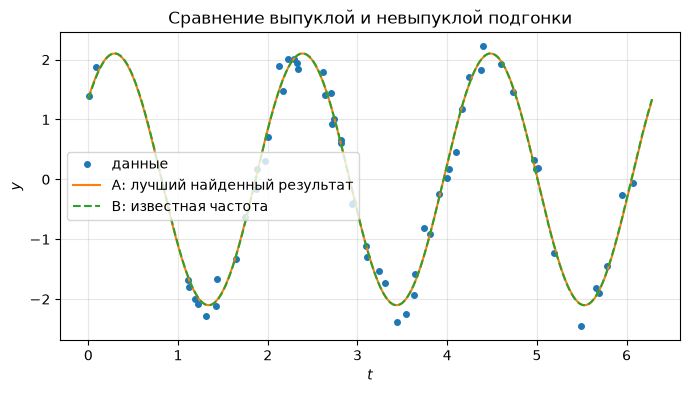

In [6]:
def model_A(t_values, x):
    return x[0] * np.sin(x[1] * t_values + x[2])

def fun_A(x):
    r = model_A(t, x) - y
    return 0.5 * (r @ r)

def grad_A(x):
    angle = x[1]*t + x[2]
    r = model_A(t, x)-y
    J = np.column_stack([np.sin(angle), x[0]*t*np.cos(angle), x[0]*np.cos(angle)])
    return J.T @ r

D = np.column_stack([np.sin(omega*t), np.cos(omega*t)])
def fun_B(x):
    r = D@x-y
    return 0.5*(r@r)
def grad_B(x):
    return D.T@(D@x-y)

print("Ранг D:", np.linalg.matrix_rank(D))
print("Собственные числа гессиана B:", np.linalg.eigvalsh(D.T@D))
results_A = [minimize(fun_A, start.copy(), jac=grad_A, method="BFGS",
                      options={"gtol": 1e-7, "maxiter": 2000}) for start in starts]
results_B = [minimize(fun_B, start[:2].copy(), jac=grad_B, method="BFGS",
                      options={"gtol": 1e-7, "maxiter": 2000}) for start in starts]
values_A = np.array([r.fun for r in results_A])
values_B = np.array([r.fun for r in results_B])
print("start | f_A | f_B | success_A | success_B | norm(grad_A) | norm(grad_B)")
for i, (rA, rB) in enumerate(zip(results_A, results_B), 1):
    print(f"{i:2d} | {rA.fun:12.8f} | {rB.fun:12.8f} | {str(rA.success):5s} | {str(rB.success):5s} | {np.linalg.norm(grad_A(rA.x)):.2e} | {np.linalg.norm(grad_B(rB.x)):.2e}")
    if not rA.success:
        print("   A:", rA.message)
tol = 1e-6  # допуск сравнения итоговых значений цели
fraction_A = np.mean(np.abs(values_A-values_A.min()) <= tol)
fraction_B = np.mean(np.abs(values_B-values_B.min()) <= tol)
print("Доля лучших стартов A:", fraction_A)
print("Доля лучших стартов B:", fraction_B)
best_A = results_A[np.argmin(values_A)]
best_B = results_B[np.argmin(values_B)]
x_B_direct, *_ = np.linalg.lstsq(D, y, rcond=None)
print("Проверка B через lstsq: разница значений f =", best_B.fun-fun_B(x_B_direct))
amplitude = np.hypot(*best_B.x)
phase = np.arctan2(best_B.x[1], best_B.x[0])
print("Лучшие параметры A:", best_A.x)
print("Параметры B:", best_B.x)
print("Амплитуда и фаза из B:", amplitude, phase)
print("f_B - f_A:", best_B.fun-best_A.fun)

tt = np.linspace(0, 2*np.pi, 800)
plt.figure(figsize=(8, 4))
plt.plot(t, y, "o", ms=4, label="данные")
plt.plot(tt, model_A(tt, best_A.x), label="A: лучший найденный результат")
plt.plot(tt, best_B.x[0]*np.sin(omega*tt)+best_B.x[1]*np.cos(omega*tt), "--", label="B: известная частота")
plt.xlabel("$t$"); plt.ylabel("$y$"); plt.legend(); plt.grid(alpha=0.3)
plt.title("Сравнение выпуклой и невыпуклой подгонки")
plt.show()
assert np.max(np.abs(values_B-fun_B(x_B_direct))) < tol
assert best_A.fun <= best_B.fun + tol

**Объяснение (пункт 3)**

**Ответ.** Для B все 20 стартов приходят к одному значению цели с допуском $10^{-6}$: у строго выпуклой задачи единственный минимум, и любой локальный минимум глобален. Для A часть стартов приводит к существенно большим значениям цели: теорема о глобальности локального минимума неприменима, а периодичность и неизвестная частота создают несколько областей притяжения. Конкретные доли лучших запусков, итоговые значения, статусы солвера и нормы градиентов приведены выше; наименьшее найденное значение A не является сертификатом глобального оптимума.

В этом эксперименте $f_{A,\min}\approx1.13927310$ достигнуто в 11 из 20 запусков (55%), а $f_{B,\min}\approx1.14076401$ — в 20 из 20 (100%). Некоторые запуски A завершаются с `success=False`: у запусков 2 и 10 норма градиента ещё заметна, поэтому их результаты нельзя объявлять найденными локальными минимумами; у остальных таких запусков градиент значительно меньше, но требуемый строгий допуск солвера также не достигнут. Доли рассчитаны по близости итогового значения цели, включая эти запуски, а не по флагу `success`.

Если решение B равно $(\beta_1,\beta_2)$, то из тождества
$$R\sin(\omega t+\phi)=R\cos\phi\sin\omega t+R\sin\phi\cos\omega t$$
получаем $R=\sqrt{\beta_1^2+\beta_2^2}$, $\phi=\operatorname{atan2}(\beta_2,\beta_1)$, а соответствующие параметры A — $(R,3,\phi)$ (если $R=0$, фазу можно выбрать произвольно).

Модель B вложена в A при фиксированной частоте $3$, поэтому минимальное возможное значение A не больше минимума B. В эксперименте небольшое улучшение A получается благодаря подстройке частоты к шумным данным. Оно не делает задачу A более надёжной: требуется мультистарт, результат зависит от начального приближения, а снижение ошибки на тех же измерениях не гарантирует лучшего обобщения на новые данные.

## Бонус (+1 балл). Проекция не растягивает

Пусть $\Omega$ — выпуклое замкнутое множество, $P(p)$ — проекция точки $p$ на $\Omega$ (решение задачи $\min_{x \in \Omega} \tfrac12\Vert x - p\Vert^2$). Докажите, что для любых $p, q$

$$\Vert P(p) - P(q)\Vert \le \Vert p - q\Vert .$$

Подсказка: запишите условие оптимальности для $P(p)$ с пробной точкой $y = P(q)$ и для $P(q)$ с $y = P(p)$, сложите и примените неравенство Коши–Буняковского. Проверьте численно на шаре ($P(p) = p / \max(1, \Vert p\Vert)$) и на кубе $[-1, 1]^n$ (`np.clip`) для 1000 случайных пар точек.

**Ответ.** Предполагаем $\Omega\ne\varnothing$, чтобы проекция была определена. Обозначим $u=P(p)$, $v=P(q)$ и $d=u-v$. Условия оптимальности с пробными точками $v$ и $u$ имеют вид
$$ (u-p)^\top(v-u)\ge0,\qquad(v-q)^\top(u-v)\ge0.$$
Складывая, получаем
$$-\|d\|^2+(p-q)^\top d\ge0,$$
поэтому по неравенству Коши–Буняковского
$$\|d\|^2\le(p-q)^\top d\le\|p-q\|\,\|d\|.$$
Если $d=0$, утверждение очевидно. Иначе делим на $\|d\|$ и получаем
$$\boxed{\|P(p)-P(q)\|\le\|p-q\|}.$$
Численная проверка ниже рассматривает по 1000 пар точек для единичного шара и куба; она служит иллюстрацией доказательства.

In [7]:
pairs_rng = np.random.default_rng(2026)
P = pairs_rng.normal(0, 3, (1000, 5))
Q = pairs_rng.normal(0, 3, (1000, 5))
def project_ball(points):
    return points / np.maximum(1, np.linalg.norm(points, axis=1))[:, None]
def project_cube(points):
    return np.clip(points, -1, 1)
original_distances = np.linalg.norm(P-Q, axis=1)
for label, projection in [("шар", project_ball), ("куб", project_cube)]:
    projected_distances = np.linalg.norm(projection(P)-projection(Q), axis=1)
    difference = projected_distances-original_distances
    print(label, ": max(||P(p)-P(q)||-||p-q||) =", difference.max())
    print("Число нарушений с допуском 1e-12:", np.sum(difference > 1e-12))
    assert np.all(difference <= 1e-12)

шар : max(||P(p)-P(q)||-||p-q||) = -1.6921283788744639
Число нарушений с допуском 1e-12: 0
куб : max(||P(p)-P(q)||-||p-q||) = -0.39191532223276493
Число нарушений с допуском 1e-12: 0


---

Перед сдачей: `Kernel → Restart Kernel and Run All Cells`, убедитесь, что ни одна ячейка не падает и все ответы заполнены. Файл — `submissions/hw02/<фамилия>.ipynb`, дальше по [инструкции](../CONTRIBUTING.md).